In [ ]:
# Step 1: Import Libraries and Load Dataset
# We prepare the environment with libraries like pandas, numpy, scikit learn, matplotlib and
# seaborn for data manipulation, numerical operations, visualization and scaling. Load the dataset for preprocessing.

from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
import pandas as pd         # load + manipulate data (DataFrame)
import numpy as np      # numerical operations (mean, std, arrays)
from sklearn.preprocessing import MinMaxScaler,StandardScaler     # feature scaling
import seaborn as sns      # statistical visualizations (prettier plots)
import matplotlib.pyplot as plt    # base plotting library (seaborn builds on this)

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Step 2: Inspect Data Structure and Check Missing Values

# We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

# df.info(): Prints concise summary including count of non-null entries and data type of each column.
# df.isnull().sum(): Returns the number of missing values per column.

df.info()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


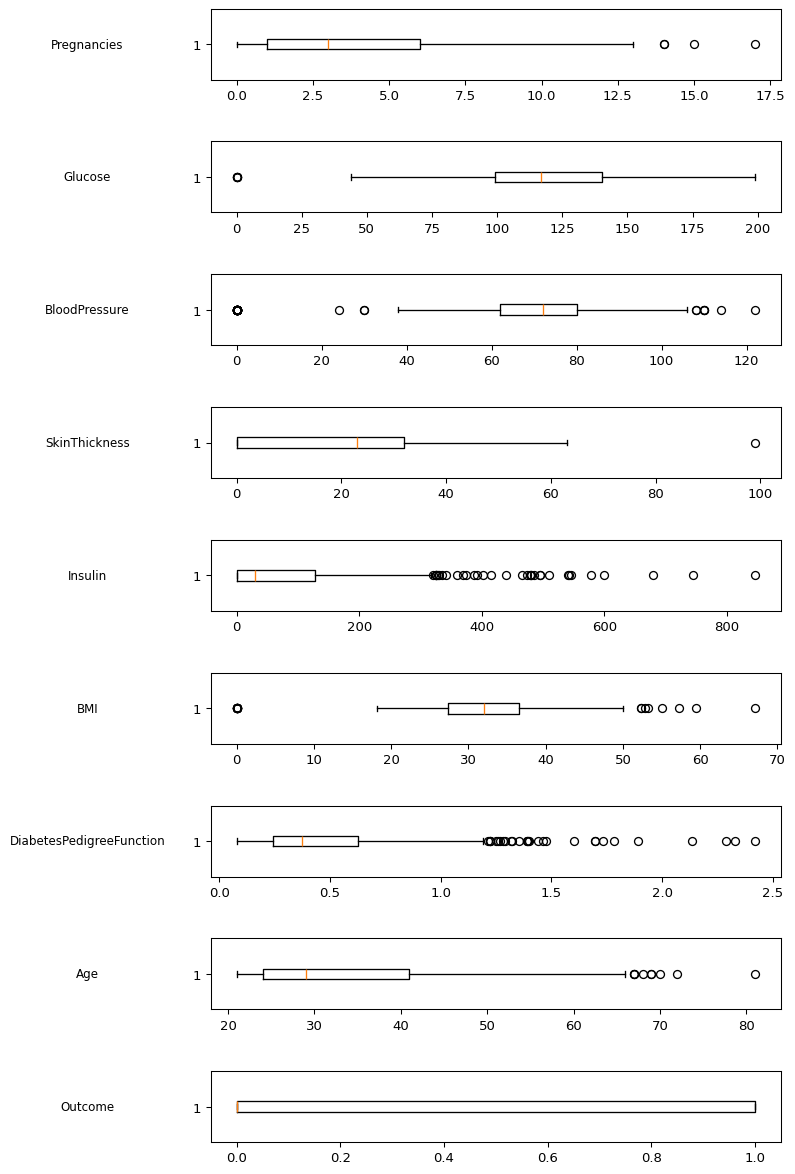

In [ ]:
# Step 3: Statistical Summary and Visualizing Outliers
# Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

# df.describe(): Computes count, mean, std deviation, min/max and quartiles for numerical columns.
# Boxplots: Visualize spread and detect outliers using matplotlib’s boxplot().

df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(9, 13), dpi= 95) # plt.subplots() →    creates a grid of multiple plots in one figure,
# len(df.columns) →    number of rows in the grid, 1 → number of columns in the grid (just 1 wide)
# figsize=(7, 8) →    width=7 inches, height=8 inches (overall figure size)
# dpi=95 →    resolution (dots per inch) — higher = sharper image
# fig →    the overall figure/canvas (the whole thing)
# axs →    array of individual plot areas (one per column), like 9 separate "slots" to draw in


for i, col in enumerate(df.columns):  # enumerate() gives you both the index number (i) and the column name (col) at the same time
  axs[i].boxplot(df[col], vert=False) # draws a horizontal box plot for that column in slot i
  axs[i].set_ylabel(col,fontsize=9, rotation=0, labelpad=80, va='center')

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
# Step 4: Remove Outliers Using the Interquartile Range (IQR) Method
# Remove extreme values beyond a reasonable range to improve model robustness.

# IQR = Q3 (75th percentile) – Q1 (25th percentile).
# Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.
# Calculate lower and upper bounds for each column separately.
# Filter data points to keep only those within bounds.

q1, q3 = np.percentile(df['Insulin'], [25, 75]) # Percentile = the value below which a certain % of your data falls.
# df['insulin'] → the Insulin column
# [25, 75] → asking for both the 25th and 75th percentile at once
# q1, q3 = → unpacks the two results into two separate variables simultaneously

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

clean_df = df[(df['Insulin'] >= lower ) & (df['Insulin'] <= upper ) ]

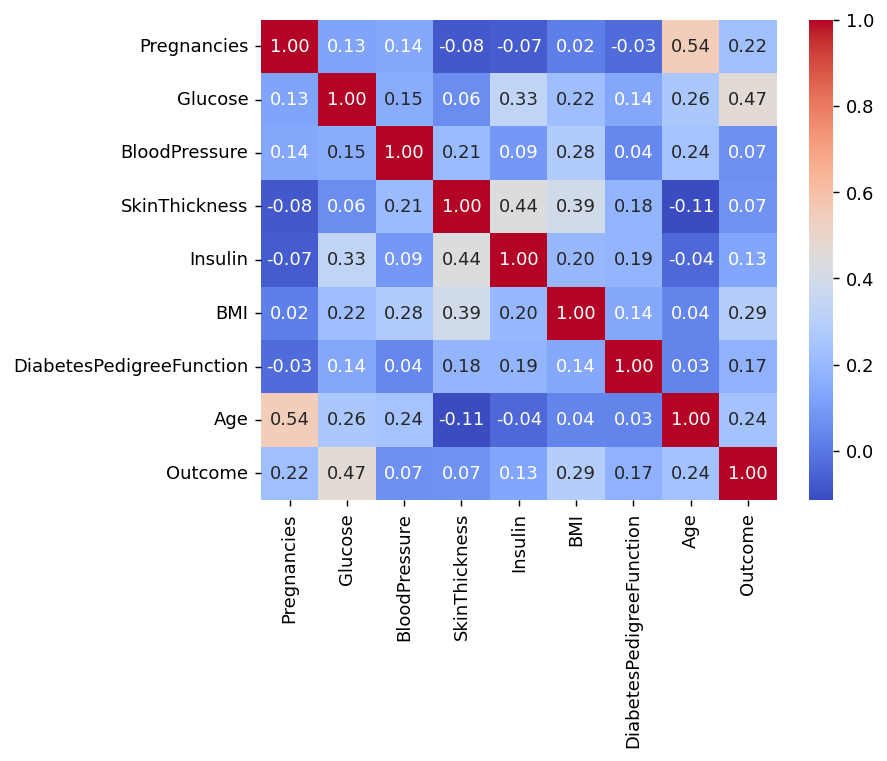

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
# Step 5: Correlation Analysis
# Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

# df.corr(): Computes pairwise correlation coefficients between columns.
# Heatmap via seaborn visualizes correlation matrix clearly.
# Sorting correlations with corr['Outcome'].sort_values() highlights features most correlated with the target.

corr = df.corr() # .corr() → calculates correlation between each pair of numeric columns

plt.figure(dpi=130) # dpi=130 → higher resolution/sharpness

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm') # a Seaborn function used to visualize data as a color-coded matrix.
# annot=True → show the actual number inside each cell

plt.show()

print(corr['Outcome'].sort_values(ascending=False))
# corr['Outcome'] → grabs just the Outcome column from the correlation matrix — showing how every other feature correlates with Outcome (the target variable)
# .sort_values(ascending=False) → sorts from highest to lowest correlation - .sort_values() comes from Pandas.

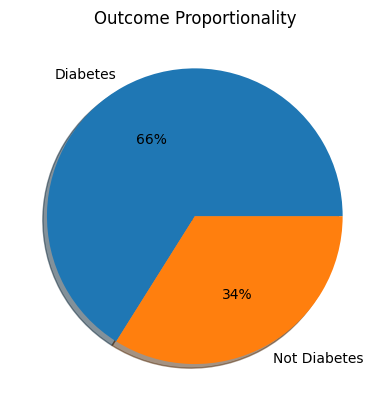

In [ ]:
# Step 6: Visualize Target Variable Distribution
# Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

# plt.pie(): Pie chart to display proportion of each class in the target variable 'Outcome'.

plt.pie(clean_df['Outcome'].value_counts(), # Counts how many times each value (0 and 1) appears in the Outcome column:
        labels=['Diabetes', 'Not Diabetes'],
        autopct='%.f%%', shadow=True) # → shows the percentage inside each slice (e.g. "65%", "35%") — %.f means round to nearest whole number, %% adds the % sign
plt.title('Outcome Proportionality')
plt.show()

In [ ]:
# Step 7: Separate Features and Target Variable
# Prepare independent variables (features) and dependent variable (target) separately for modeling.

# df.drop(columns=[...]): Drops the target column from features.
# Direct column selection df['Outcome'] selects target column.

X = df.drop(columns='Outcome')
y = df['Outcome']

In [ ]:
# Step 8: Feature Scaling: Normalization and Standardization
# Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

# 1. Normalization (Min-Max Scaling): Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

# Class: MinMaxScaler from sklearn.
# .fit_transform(): Learns min/max from data and applies scaling.

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5]) #  → prints first 5 rows to preview the result



[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


In [ ]:
# 2. Standardization: Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.
# Class: StandardScaler from sklearn.

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
